In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as pf
import healpy as hp

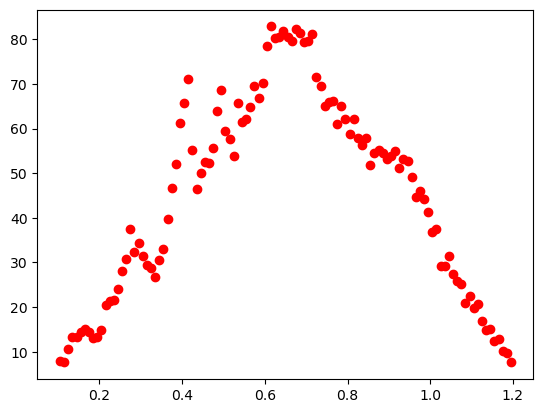

In [2]:
d = pd.read_csv("n_mean.csv")
plt.plot(d["z"], d["n_mean"], "ro")
zbin, n_mean = d["z"].values, d["n_mean"].values
plt.show()

In [3]:
dc=pf.open("y6a2_dnf_wazp_v5.0.12.6801_clusters.fits")[1]
dc.header["TTYPE*"]

TTYPE1  = 'NAME    '                                                            
TTYPE2  = 'ID      '                                                            
TTYPE3  = 'RA      '                                                            
TTYPE4  = 'DEC     '                                                            
TTYPE5  = 'ZPHOT   '                                                            
TTYPE6  = 'ZSPEC   '                                                            
TTYPE7  = 'ZSPEC_UNC'                                                           
TTYPE8  = 'ZSPEC_TYPE'                                                          
TTYPE9  = 'SNR     '                                                            
TTYPE10 = 'NGALS   '                                                            
TTYPE11 = 'NGALS_UNC'                                                           
TTYPE12 = 'RADIUS_MPC'                                                          
TTYPE13 = 'RADIUS_AMIN'     

In [4]:
df = pf.open("y6a2_dnf_wazp_v5.0.12.6801_footprint.fits")[1]
df.header["TTYPE*"]

TTYPE1  = 'PIXEL   '                                                            
TTYPE2  = 'DETFRAC '                                                            
TTYPE3  = 'ZMAX    '                                                            

In [5]:
df.header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   24 / length of dimension 1                          
NAXIS2  =             22483619 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    3 / number of table fields                         
TTYPE1  = 'PIXEL   '                                                            
TFORM1  = 'K       '                                                            
TUNIT1  = 'HEALPix pixel index'                                                 
TTYPE2  = 'DETFRAC '                                                            
TFORM2  = 'D       '        

In [6]:
dm = pf.open("y6a2_dnf_wazp_v5.0.12.6801_members.fits")[1]
dm.header["TTYPE*"]

TTYPE1  = 'ID      '                                                            
TTYPE2  = 'ID_CLUSTER'                                                          
TTYPE3  = 'RA      '                                                            
TTYPE4  = 'DEC     '                                                            
TTYPE5  = 'ZPHOT   '                                                            
TTYPE6  = 'ZSPEC   '                                                            
TTYPE7  = 'ZSPEC_SOURCE'                                                        
TTYPE8  = 'PMEM    '                                                            
TTYPE9  = 'FLAG_CG '                                                            
TTYPE10 = 'MAG_G   '                                                            
TTYPE11 = 'MAG_R   '                                                            
TTYPE12 = 'MAG_I   '                                                            
TTYPE13 = 'MAG_Z   '        

In [7]:
ra0=48.97
dec0=-19.7
zmin = 1.14
zmax = 1.18

In [8]:
Nside = 4096
Npix = hp.nside2npix(Nside)

In [9]:
theta, phi = np.deg2rad(90-dc.data["dec"]), np.deg2rad(dc.data["ra"])
ipixes = hp.ang2pix(Nside, theta, phi, nest=True)

In [10]:
ipixes_foot = df.data["PIXEL"]
ipixes_mask  = df.data["ZMAX"]>0.7
ipixes_mask &= df.data["DETFRAC"]>0.9
ipixes_valid = np.unique(ipixes_foot[ipixes_mask])

In [11]:
vec = hp.ang2vec(ra0, dec0, lonlat=True)
radius = np.deg2rad(4.5)
ipix_inside = hp.query_disc(
    Nside, vec, radius, inclusive=False, nest=True)

In [12]:
ipix_inside.shape

(310311,)

In [13]:
inside_mask = np.isin(ipixes, ipix_inside)
print (inside_mask.shape, inside_mask.sum())
inside_mask &= np.isin(ipixes, ipixes_valid)
print (inside_mask.shape, inside_mask.sum())

(416947,) 5202
(416947,) 4901


In [14]:
zp = dc.data["zphot"]

In [15]:
zbin = np.linspace(0.1, 1.2, 111)
zx = zbin[:-1] + np.diff(zbin)[0]/2.

area_mean = 543.25
area_void = 55.78

def getNcount(zp):
    n_mean = d["n_mean"]/area_void
    N_mean = n_mean *area_mean
    N_void = np.histogram(zp[inside_mask], zbin)[0]
    n_void = N_void/area_void
    R = n_void/n_mean
    delta = R-1.
    E_delta = R*np.sqrt(1./N_mean + 1./N_void)
    return delta, E_delta
delta, E_delta = getNcount(zp)

### reproduction of the Shimakawa-san's result

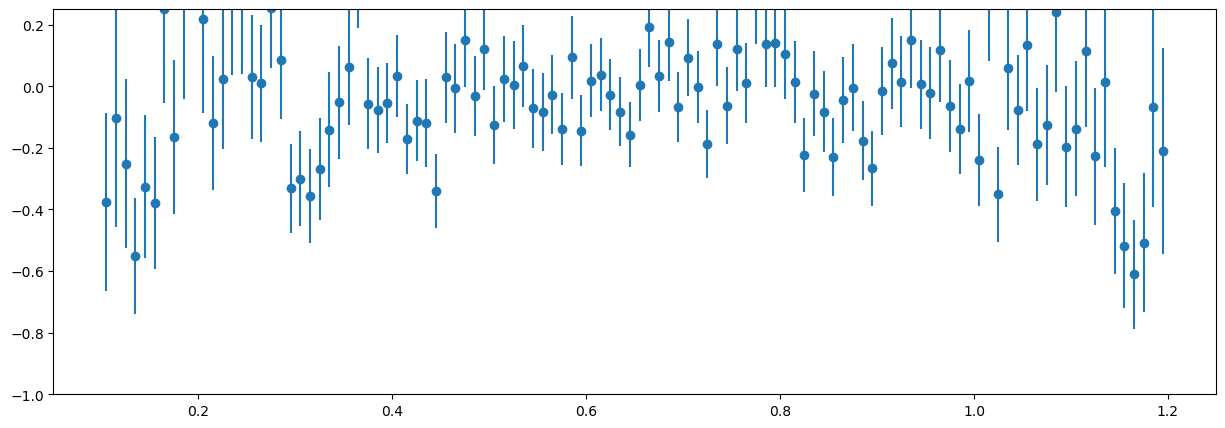

In [16]:
plt.figure(figsize=(15,5))
plt.plot(zx, delta, "C0o")
plt.errorbar(zx, delta, E_delta, color="C0", capsize=0., ls="none")
plt.ylim(-1,0.25)
plt.show()

### Photoz error model

The photo-z erorr model can be delived from photo-z spec-z comparison.  
1. use measured zp-zs relation for individual galaxies as a function of zp. But this is slightly noisy. We can use the fitted function instead, $z_{\rm err} = 0.01(1+z_p)^3$.
2. This is limited to the area where spec-z is available and sample is biased to the bright galaxies. Therefore, another way of photo-z model should be from z_err^photo as discussed in the WaZP paper, however, since this is the cluster catalog, cluster redshift is more robustly determined using the clustering information. Therefore, using the raw value of the ptotoz uncertainty is not appropriate. We propose to use $z_{\rm err}^{\rm cl}= z_{\rm err}^{\rm photoz} / \sqrt{R}$, where $R$ is richness of the cluster.

/var/folders/r3/x0t47nmj5_z_qp5h4k0010xh0000gn/T/ipykernel_82666/2337129001.py:7: RuntimeWarning: Mean of empty slice
  mean.append(np.nanmean(dc.data["zspec"][mask]))
/opt/miniconda3/envs/ana/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


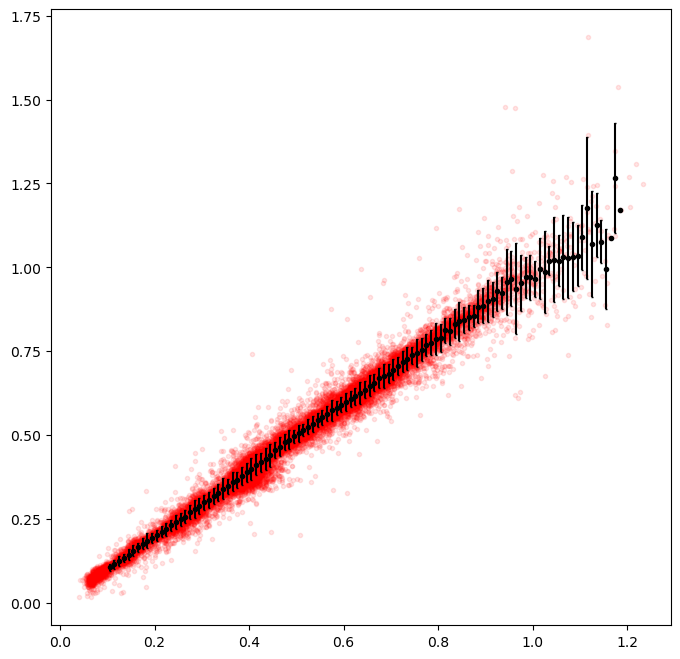

In [17]:
plt.figure(figsize=(8,8))
plt.plot(dc.data["zphot"], dc.data["zspec"], "ro", ms=3, alpha=0.1)
mean, std = [], []
for iz in range(len(zbin)-1):
    mask = dc.data["zphot"]>zbin[iz]
    mask &= dc.data["zphot"]<zbin[iz+1]
    mean.append(np.nanmean(dc.data["zspec"][mask]))
    std .append(np.nanstd (dc.data["zspec"][mask]))
plt.errorbar(zx, mean, std, ls="none", capsize=1, color="k", marker="o", ms=3)
plt.show()

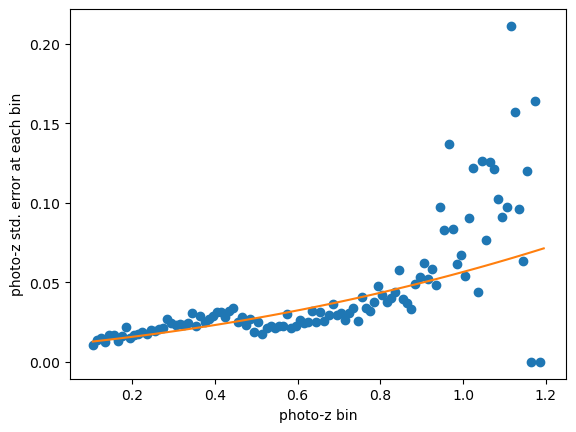

In [18]:
plt.plot(zx, std, "C0o", label="WaZP catalog")
plt.plot(zx, 0.01*(1+zx)**2.5, "C1-", label="fitting")
plt.ylabel("photo-z std. error at each bin")
plt.xlabel("photo-z bin")
plt.show()

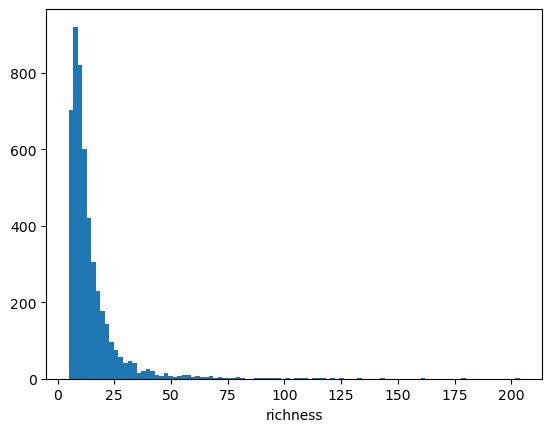

In [19]:
plt.hist(dc.data["NGALS"][inside_mask], bins=100)
plt.xlabel("richness")
plt.show()

we take the option 2 for photo-z error for cluster and fluctuate the cluster redshift in 1000 times. Shot noise for each iteration can be propagated to the total error.   
$$ \sigma_{{\rm tot},i}^2 = \frac{1}{N_{\rm mc}-1}\sum_{k}^{N_{\rm mc}}(\delta_{i,k}-\bar{\delta_i})^2 + \frac{1}{N_{\rm mc}}\sum_k^{N_{\rm mc}}\sigma_{\rm shot,i,k}^2 $$
where $\delta_{i,k}$ is the density fluctuation of $i-$th bin for $k-$th iteration out of 1000 sampling.

In [24]:
Nmc = 1000
delta_sample_arr, E_delta_sample_arr = [], []
for imcmc in range(Nmc):
    zp_sample = np.random.normal(loc=zp, scale=0.21/np.sqrt(dc.data["NGALS"]))
    delta_sample, E_delta_sample = getNcount(zp_sample)
    delta_sample_arr.append(delta_sample)
    E_delta_sample_arr.append(E_delta_sample)
delta_sample_arr, E_delta_sample_arr = np.array(delta_sample_arr), np.array(E_delta_sample_arr)
E_delta_tot = np.sqrt(np.nanvar(delta_sample_arr,axis=0)+np.nanmean(E_delta_sample_arr**2.,axis=0))

/var/folders/r3/x0t47nmj5_z_qp5h4k0010xh0000gn/T/ipykernel_82666/1532377264.py:14: RuntimeWarning: divide by zero encountered in divide
  E_delta = R*np.sqrt(1./N_mean + 1./N_void)


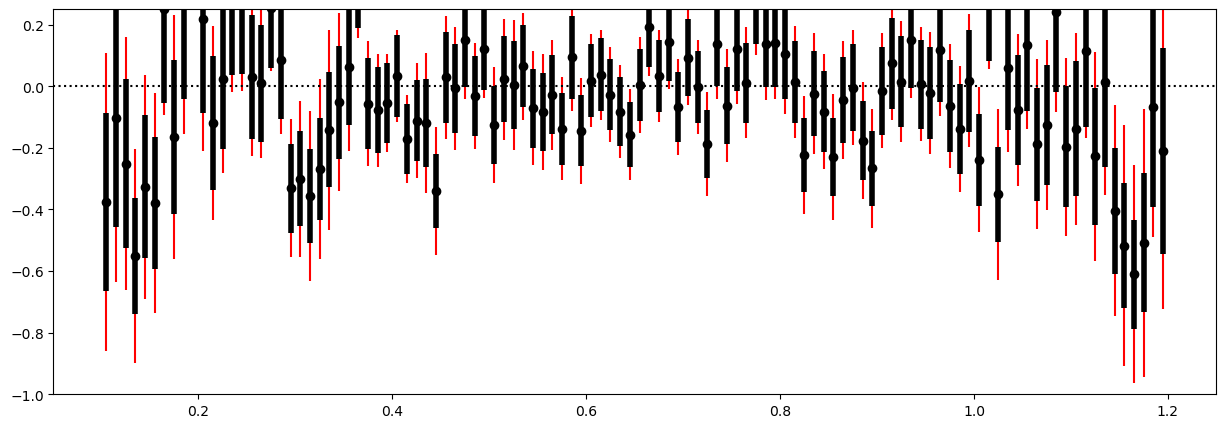

In [25]:
plt.figure(figsize=(15,5))
plt.plot(zx, delta, "ko")
plt.errorbar(zx, delta, E_delta_tot, color="r", capsize=0., ls="none")
plt.errorbar(zx, delta, E_delta, color="k", capsize=0., ls="none", lw=4)
plt.axhline(y=0, ls=":", color="k")
plt.ylim(-1,0.25)
plt.show()

In [22]:
df = pd.DataFrame(
    {"z_mid": zx,
     "delta": delta,
     "delta_err_SN": E_delta,
     "delta_err_tot": E_delta_tot
    })
df.to_csv("CS_void_zdist_WaZPCluster.csv", index=False, float_format="%6.4f")